## What is meant by invasive ductal carcinoma? <a class="anchor" id="intro"></a>

<a title="Mikael Häggström, M.D. - Author info - Reusing images [CC BY (https://creativecommons.org/licenses/by/2.5)]" href="https://commons.wikimedia.org/wiki/File:Lobules_and_ducts_of_the_breast.jpg"><img width="309" alt="Lobules and ducts of the breast" style="float:left; margin:0px 15px 15px 15px" src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/Lobules_and_ducts_of_the_breast.jpg/256px-Lobules_and_ducts_of_the_breast.jpg"></a>


This illustration created [Mikael Häggström](https://commons.wikimedia.org/wiki/File:Lobules_and_ducts_of_the_breast.jpg) shows the anatomy of a healthy breast. One can see the lobules, the glands that can produce milk which flews through the milk ducts. Ductal carcinoma starts to develop in the ducts whereas lobular carcinoma has its origin in the lobules. Invasive carcinoma is able to leave its initial tissue compartment and can form metastases.

In [1]:
!pip install torch torchvision Pillow

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR, CyclicLR
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight


from glob import glob
from skimage.io import imread
from os import listdir

import time
import copy
from tqdm import tqdm_notebook as tqdm

### Settings

In [3]:
run_training = False
retrain = True
find_learning_rate = True

## Exploring the data structure <a class="anchor" id="explorestructure"></a>

In [4]:
files = listdir("/kaggle/input/idc-brest-cancer/archive_2")
print(len(files))

280


In [5]:
files[0:10]

['10295',
 '10304',
 '12868',
 '10274',
 '12818',
 '14190',
 '12869',
 '9323',
 '10291',
 '12906']

In [6]:
# files = listdir("../input/breast-histopathology-images/IDC_regular_ps50_idx5/")
# len(files)

In [7]:
base_path = "/kaggle/input/idc-brest-cancer/archive_2"
folder = listdir(base_path)
len(folder)

280

In [8]:
import os

total_images = 0
for n in range(len(folder)):
    patient_id = folder[n]
    for c in [0, 1]:
        patient_path = os.path.join(base_path, patient_id)
        class_path = os.path.join(patient_path, str(c))
        
        # Check if the directory exists
        if os.path.exists(class_path):
            subfiles = os.listdir(class_path)
            total_images += len(subfiles)
        else:
            # Handle missing directories
            print(f"Directory not found: {class_path}")

print(f"Total images: {total_images}")

Directory not found: /kaggle/input/idc-brest-cancer/archive_2/IDC_regular_ps50_idx5/0
Directory not found: /kaggle/input/idc-brest-cancer/archive_2/IDC_regular_ps50_idx5/1
Total images: 277524


In [9]:
total_images

277524

### Storing the image_path, patient_id and the target

In [10]:
import os
import pandas as pd
import numpy as np

# Initialize the DataFrame
data = pd.DataFrame(index=np.arange(0, total_images), columns=["patient_id", "path", "target"])

k = 0
for n in range(len(folder)):
    patient_id = folder[n]
    patient_path = os.path.join(base_path, patient_id)
    
    for c in [0, 1]:
        class_path = os.path.join(patient_path, str(c))
        
        # Check if the class directory exists before accessing it
        if os.path.exists(class_path):
            subfiles = os.listdir(class_path)
            
            for m in range(len(subfiles)):
                image_path = subfiles[m]
                
                # Fill the DataFrame
                data.iloc[k]["path"] = os.path.join(class_path, image_path)
                data.iloc[k]["target"] = c
                data.iloc[k]["patient_id"] = patient_id
                
                k += 1
        else:
            # Log if the directory doesn't exist
            print(f"Directory not found: {class_path}")

# Show the first few rows of the DataFrame
data.head()


Directory not found: /kaggle/input/idc-brest-cancer/archive_2/IDC_regular_ps50_idx5/0
Directory not found: /kaggle/input/idc-brest-cancer/archive_2/IDC_regular_ps50_idx5/1


,patient_id,path,target
0,10295,/kaggle/input/idc-brest-cancer/archive_2/10295...,0
1,10295,/kaggle/input/idc-brest-cancer/archive_2/10295...,0
2,10295,/kaggle/input/idc-brest-cancer/archive_2/10295...,0
3,10295,/kaggle/input/idc-brest-cancer/archive_2/10295...,0
4,10295,/kaggle/input/idc-brest-cancer/archive_2/10295...,0


In [11]:
data.shape

(277524, 3)

# Exploratory analysis <a class="anchor" id="eda"></a>

## What do we know about our data? <a class="anchor" id="data"></a>

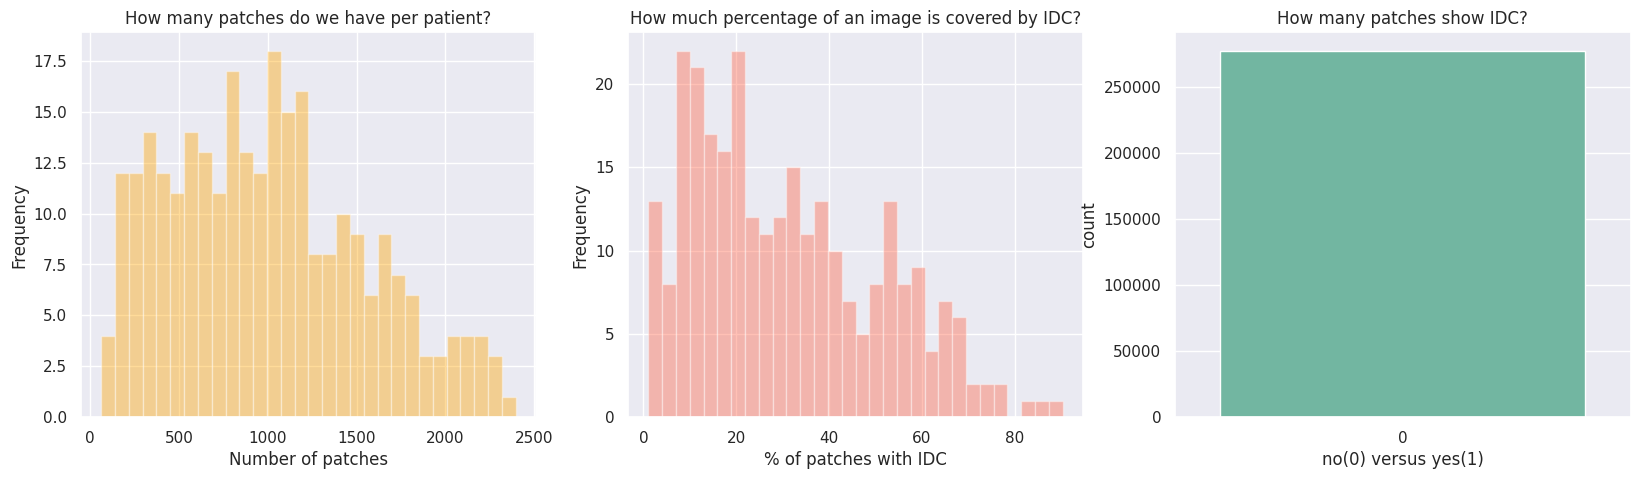

In [12]:
cancer_perc = data.groupby("patient_id").target.value_counts()/ data.groupby("patient_id").target.size()
cancer_perc = cancer_perc.unstack()

fig, ax = plt.subplots(1,3,figsize=(20,5))
sns.distplot(data.groupby("patient_id").size(), ax=ax[0], color="Orange", kde=False, bins=30)
ax[0].set_xlabel("Number of patches")
ax[0].set_ylabel("Frequency");
ax[0].set_title("How many patches do we have per patient?");
sns.distplot(cancer_perc.loc[:, 1]*100, ax=ax[1], color="Tomato", kde=False, bins=30)
ax[1].set_title("How much percentage of an image is covered by IDC?")
ax[1].set_ylabel("Frequency")
ax[1].set_xlabel("% of patches with IDC");
sns.countplot(data.target, palette="Set2", ax=ax[2]);
ax[2].set_xlabel("no(0) versus yes(1)")
ax[2].set_title("How many patches show IDC?");

## Looking at healthy and cancer patches <a class="anchor" id="patches"></a>

In [13]:
data.target = data.target.astype(np.int64)

In [14]:
pos_selection = np.random.choice(data[data.target==1].index.values, size=50, replace=False)
neg_selection = np.random.choice(data[data.target==0].index.values, size=50, replace=False)

### Cancer patches

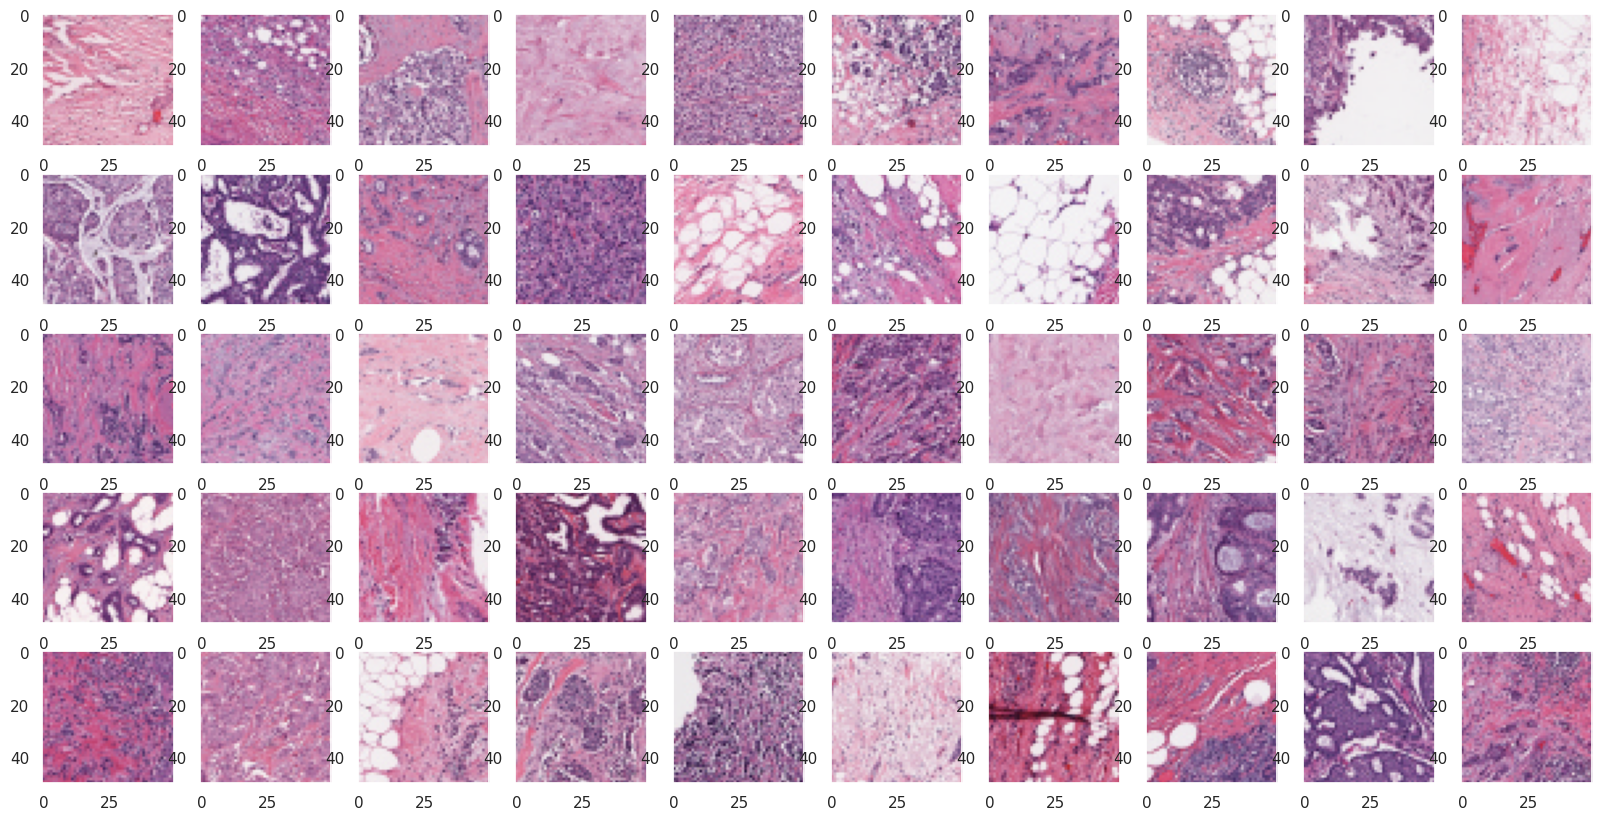

In [15]:
fig, ax = plt.subplots(5,10,figsize=(20,10))

for n in range(5):
    for m in range(10):
        idx = pos_selection[m + 10*n]
        image = imread(data.loc[idx, "path"])
        ax[n,m].imshow(image)
        ax[n,m].grid(False)

### Healthy patches

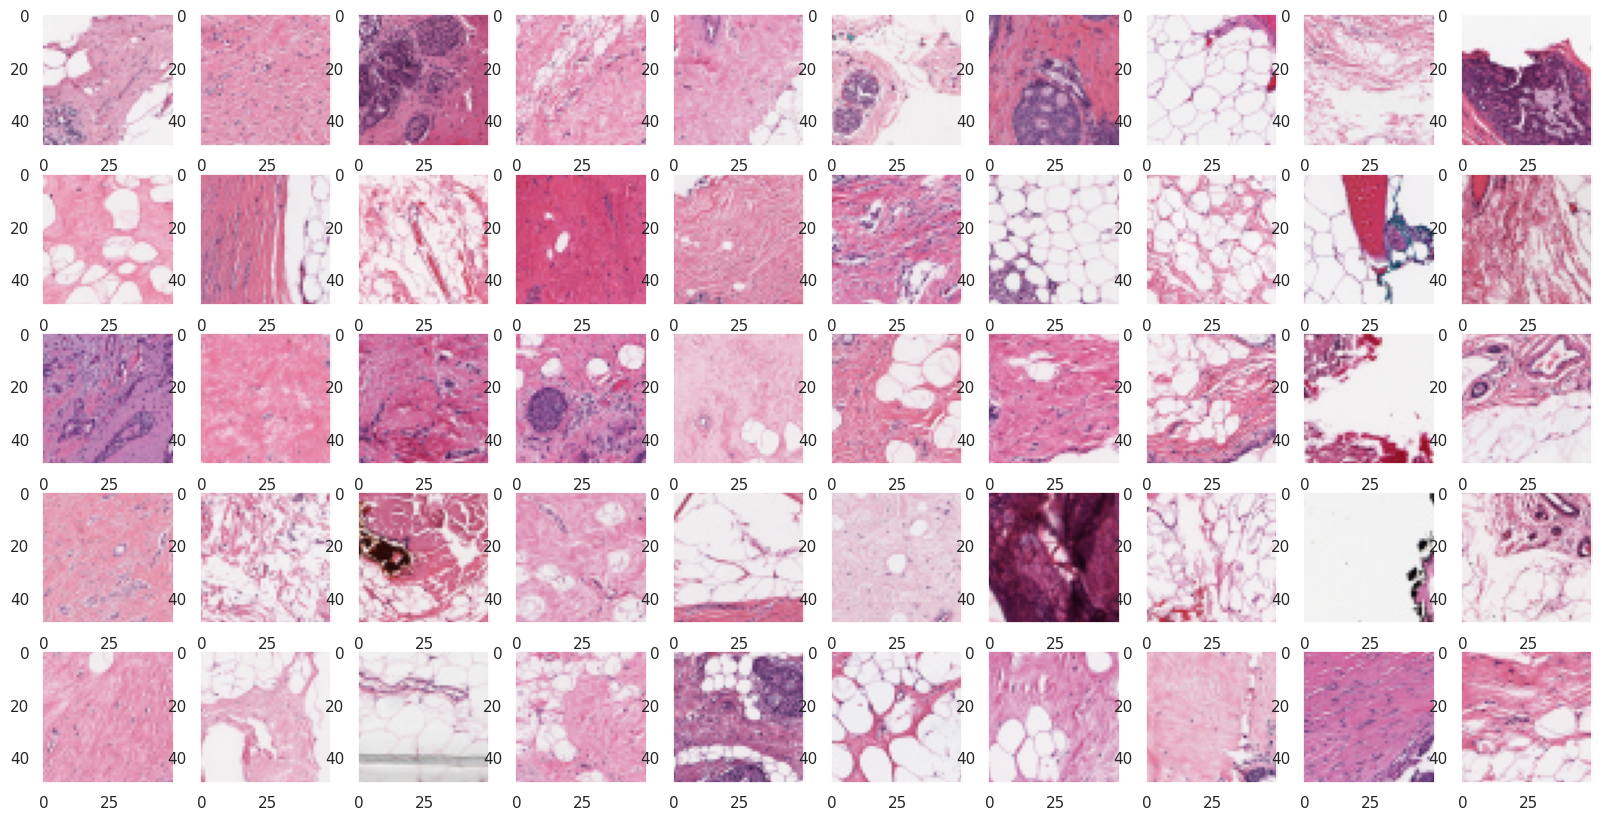

In [16]:
fig, ax = plt.subplots(5,10,figsize=(20,10))

for n in range(5):
    for m in range(10):
        idx = neg_selection[m + 10*n]
        image = imread(data.loc[idx, "path"])
        ax[n,m].imshow(image)
        ax[n,m].grid(False)

In [17]:
def extract_coords(df):
    coord = df.path.str.rsplit("_", n=4, expand=True)
    coord = coord.drop([0, 1, 4], axis=1)
    coord = coord.rename({2: "x", 3: "y"}, axis=1)
    coord.loc[:, "x"] = coord.loc[:,"x"].str.replace("x", "", case=False).astype(np.int64)
    coord.loc[:, "y"] = coord.loc[:,"y"].str.replace("y", "", case=False).astype(np.int64)
    df.loc[:, "x"] = coord.x.values
    df.loc[:, "y"] = coord.y.values
    return df

def get_cancer_dataframe(patient_id, cancer_id):
    path = base_path + patient_id + "/" + cancer_id
    files = listdir(path)
    dataframe = pd.DataFrame(files, columns=["filename"])
    path_names = path + "/" + dataframe.filename.values
    dataframe = dataframe.filename.str.rsplit("_", n=4, expand=True)
    dataframe.loc[:, "target"] = np.int64(cancer_id)
    dataframe.loc[:, "path"] = path_names
    dataframe = dataframe.drop([0, 1, 4], axis=1)
    dataframe = dataframe.rename({2: "x", 3: "y"}, axis=1)
    dataframe.loc[:, "x"] = dataframe.loc[:,"x"].str.replace("x", "", case=False).astype(np.int64)
    dataframe.loc[:, "y"] = dataframe.loc[:,"y"].str.replace("y", "", case=False).astype(np.int64)
    return dataframe

def get_patient_dataframe(patient_id):
    df_0 = get_cancer_dataframe(patient_id, "0")
    print(df_0)
    df_1 = get_cancer_dataframe(patient_id, "1")
    print(df_1)
    # patient_df = df_0.concat(df_1)
    patient_df = pd.concat([df_0, df_1])
    return patient_df

In [18]:
import os
import pandas as pd

# Function to get cancer dataframe
def get_cancer_dataframe(patient_id, cancer_id):
    path = os.path.join(base_path, patient_id, cancer_id)  # Construct the path
    if os.path.exists(path):  # Check if the directory exists
        files = os.listdir(path)  # List files in the directory
        dataframe = pd.DataFrame(files, columns=["filename"])
        dataframe["path"] = dataframe["filename"].apply(lambda x: os.path.join(path, x))
        return dataframe
    else:
        print(f"Directory not found: {path}")
        return pd.DataFrame()  # Return an empty dataframe if directory doesn't exist

# Function to get patient dataframe
def get_patient_dataframe(patient_id):
    df_0 = get_cancer_dataframe(patient_id, "0")  # Get dataframe for class 0
    df_1 = get_cancer_dataframe(patient_id, "1")  # Get dataframe for class 1
    return pd.concat([df_0, df_1], ignore_index=True)  # Concatenate the two dataframes

# Example usage
example = get_patient_dataframe(data.patient_id.values[0])
example


,filename,path
0,10295_idx5_x1351_y1101_class0.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
1,10295_idx5_x1501_y501_class0.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
2,10295_idx5_x1501_y1101_class0.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
3,10295_idx5_x451_y901_class0.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
4,10295_idx5_x801_y451_class0.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
...,...,...
890,10295_idx5_x1401_y1801_class1.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
891,10295_idx5_x1101_y1651_class1.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
892,10295_idx5_x1251_y1551_class1.png,/kaggle/input/idc-brest-cancer/archive_2/10295...
893,10295_idx5_x1551_y1501_class1.png,/kaggle/input/idc-brest-cancer/archive_2/10295...


Ok, now we have the coordinates for each patch, its path to load the image and its target information.

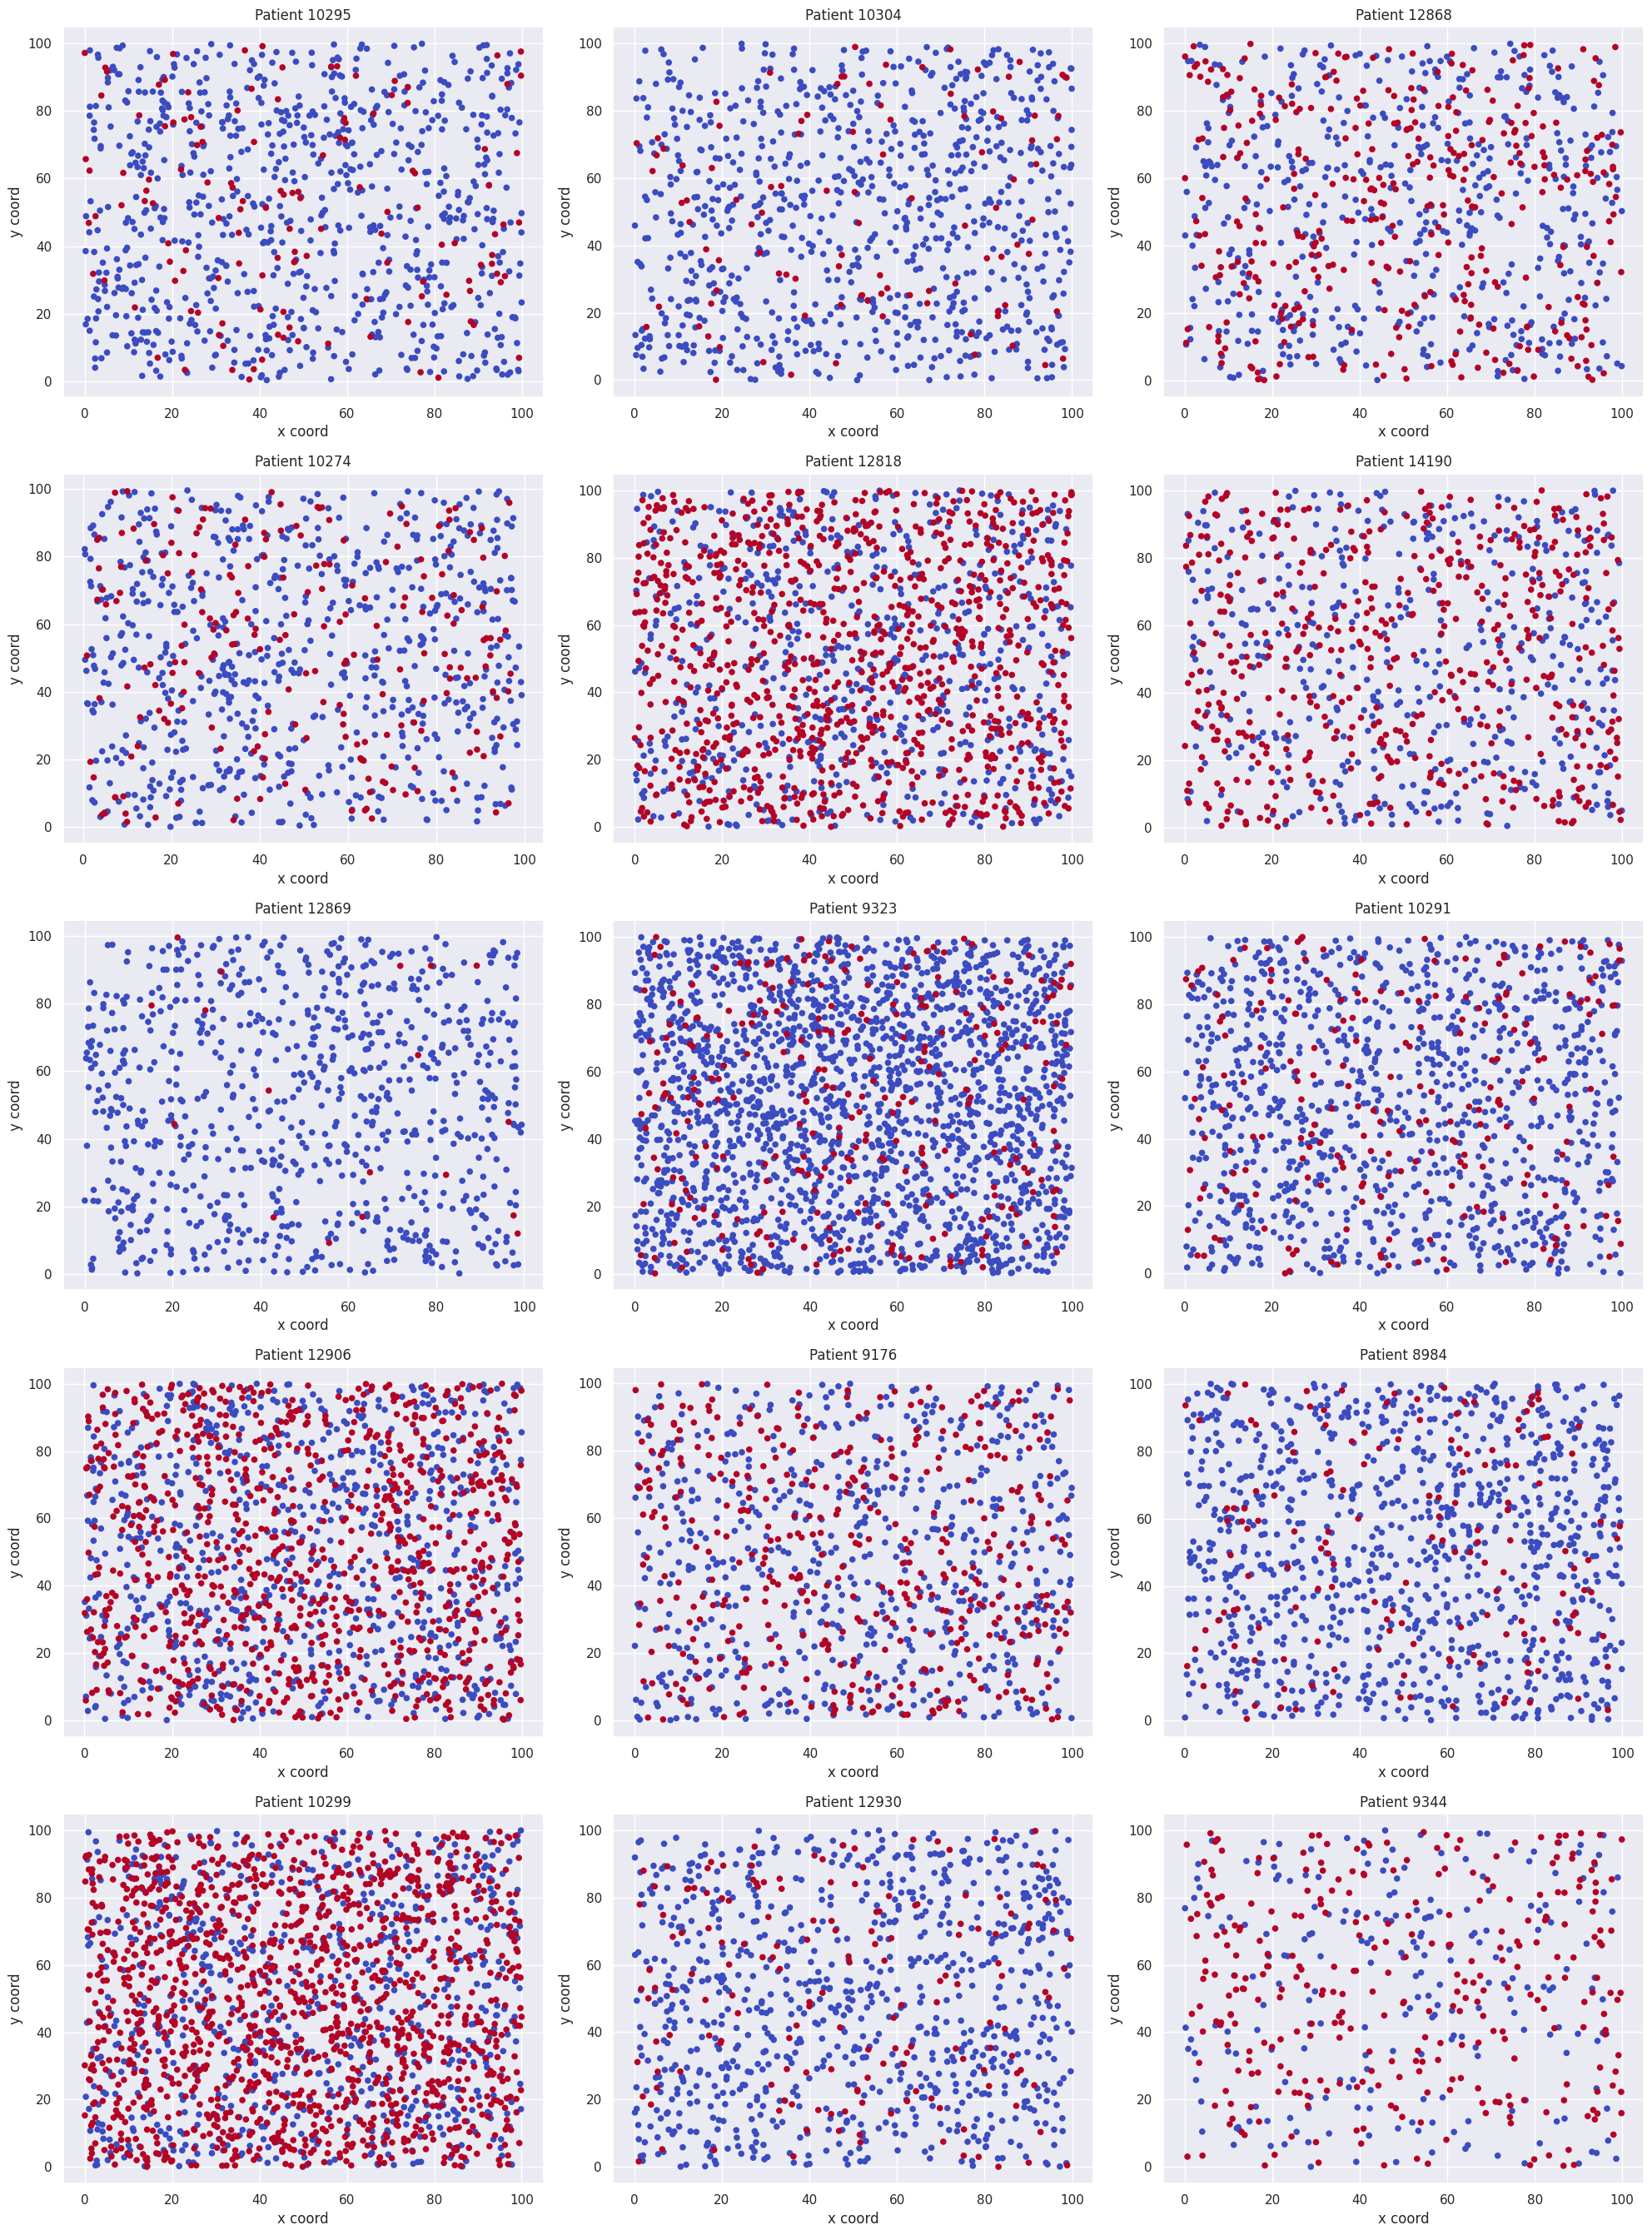

In [19]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Modify the get_cancer_dataframe to load or simulate x and y values
def get_cancer_dataframe(patient_id, cancer_id):
    path = os.path.join(base_path, patient_id, cancer_id)
    
    if os.path.exists(path):
        files = os.listdir(path)
        dataframe = pd.DataFrame(files, columns=["filename"])
        dataframe["path"] = dataframe["filename"].apply(lambda x: os.path.join(path, x))
        
        # Simulate x and y coordinates if they're not available in the dataset
        dataframe["x"] = np.random.uniform(0, 100, size=len(dataframe))  # Simulated x values
        dataframe["y"] = np.random.uniform(0, 100, size=len(dataframe))  # Simulated y values
        dataframe["target"] = int(cancer_id)  # Assign target class based on cancer_id (0 or 1)
        
        return dataframe
    else:
        print(f"Directory not found: {path}")
        return pd.DataFrame()  # Return an empty DataFrame if directory doesn't exist

# Function to get patient dataframe
def get_patient_dataframe(patient_id):
    df_0 = get_cancer_dataframe(patient_id, "0")  # DataFrame for class 0
    df_1 = get_cancer_dataframe(patient_id, "1")  # DataFrame for class 1
    return pd.concat([df_0, df_1], ignore_index=True)  # Concatenate both DataFrames

# Example plotting code
fig, ax = plt.subplots(5, 3, figsize=(20, 27))

patient_ids = data.patient_id.unique()

for n in range(5):
    for m in range(3):
        patient_id = patient_ids[m + 3 * n]
        example_df = get_patient_dataframe(patient_id)
        
        if not example_df.empty:
            # Scatter plot using x and y coordinates, and target for coloring
            ax[n, m].scatter(example_df.x.values, example_df.y.values, c=example_df.target.values, cmap="coolwarm", s=20)
            ax[n, m].set_title("Patient " + patient_id)
            ax[n, m].set_xlabel("x coord")
            ax[n, m].set_ylabel("y coord")
        else:
            ax[n, m].set_title(f"Patient {patient_id} (No data)")
            ax[n, m].set_axis_off()  # Hide axis if no data available

plt.tight_layout()
plt.show()


In [20]:
def visualise_breast_tissue(patient_id, pred_df=None):
    example_df = get_patient_dataframe(patient_id)
    print(example_df)
    max_point = [example_df.y.max()-1, example_df.x.max()-1]
    grid = 255*np.ones(shape = (max_point[0] + 50, max_point[1] + 50, 3)).astype(np.uint8)
    mask = 255*np.ones(shape = (max_point[0] + 50, max_point[1] + 50, 3)).astype(np.uint8)
    if pred_df is not None:
        patient_df = pred_df[pred_df.patient_id == patient_id].copy()
    mask_proba = np.zeros(shape = (max_point[0] + 50, max_point[1] + 50, 1)).astype(np.float64)

    broken_patches = []
    for n in range(len(example_df)):
        try:
            image = imread(example_df.path.values[n])

            target = example_df.target.values[n]

            x_coord = np.int64(example_df.x.values[n])
            y_coord = np.int64(example_df.y.values[n])
            x_start = x_coord - 1
            y_start = y_coord - 1
            x_end = x_start + 50
            y_end = y_start + 50

            grid[y_start:y_end, x_start:x_end] = image
            if target == 1:
                mask[y_start:y_end, x_start:x_end, 0] = 250
                mask[y_start:y_end, x_start:x_end, 1] = 0
                mask[y_start:y_end, x_start:x_end, 2] = 0
            if pred_df is not None:

                proba = patient_df[
                    (patient_df.x==x_coord) & (patient_df.y==y_coord)].proba
                mask_proba[y_start:y_end, x_start:x_end, 0] = np.float64(proba)

        except ValueError:
            broken_patches.append(example_df.path.values[n])


    return grid, mask, broken_patches, mask_proba

Let's use an example patient with id 13616:

                               filename  \
0      13616_idx5_x2001_y801_class0.png   
1      13616_idx5_x2151_y801_class0.png   
2     13616_idx5_x1951_y1901_class0.png   
3     13616_idx5_x1801_y1751_class0.png   
4     13616_idx5_x1951_y2301_class0.png   
...                                 ...   
1352  13616_idx5_x2301_y1701_class1.png   
1353  13616_idx5_x1501_y2151_class1.png   
1354  13616_idx5_x1951_y2051_class1.png   
1355  13616_idx5_x1101_y1601_class1.png   
1356  13616_idx5_x1551_y2201_class1.png   

                                                   path          x          y  \
0     /kaggle/input/idc-brest-cancer/archive_2/13616...  95.188473  66.765562   
1     /kaggle/input/idc-brest-cancer/archive_2/13616...  59.840302  30.384738   
2     /kaggle/input/idc-brest-cancer/archive_2/13616...  95.773207  59.394357   
3     /kaggle/input/idc-brest-cancer/archive_2/13616...   0.827134  74.180198   
4     /kaggle/input/idc-brest-cancer/archive_2/13616...   0.685248  34.151704 

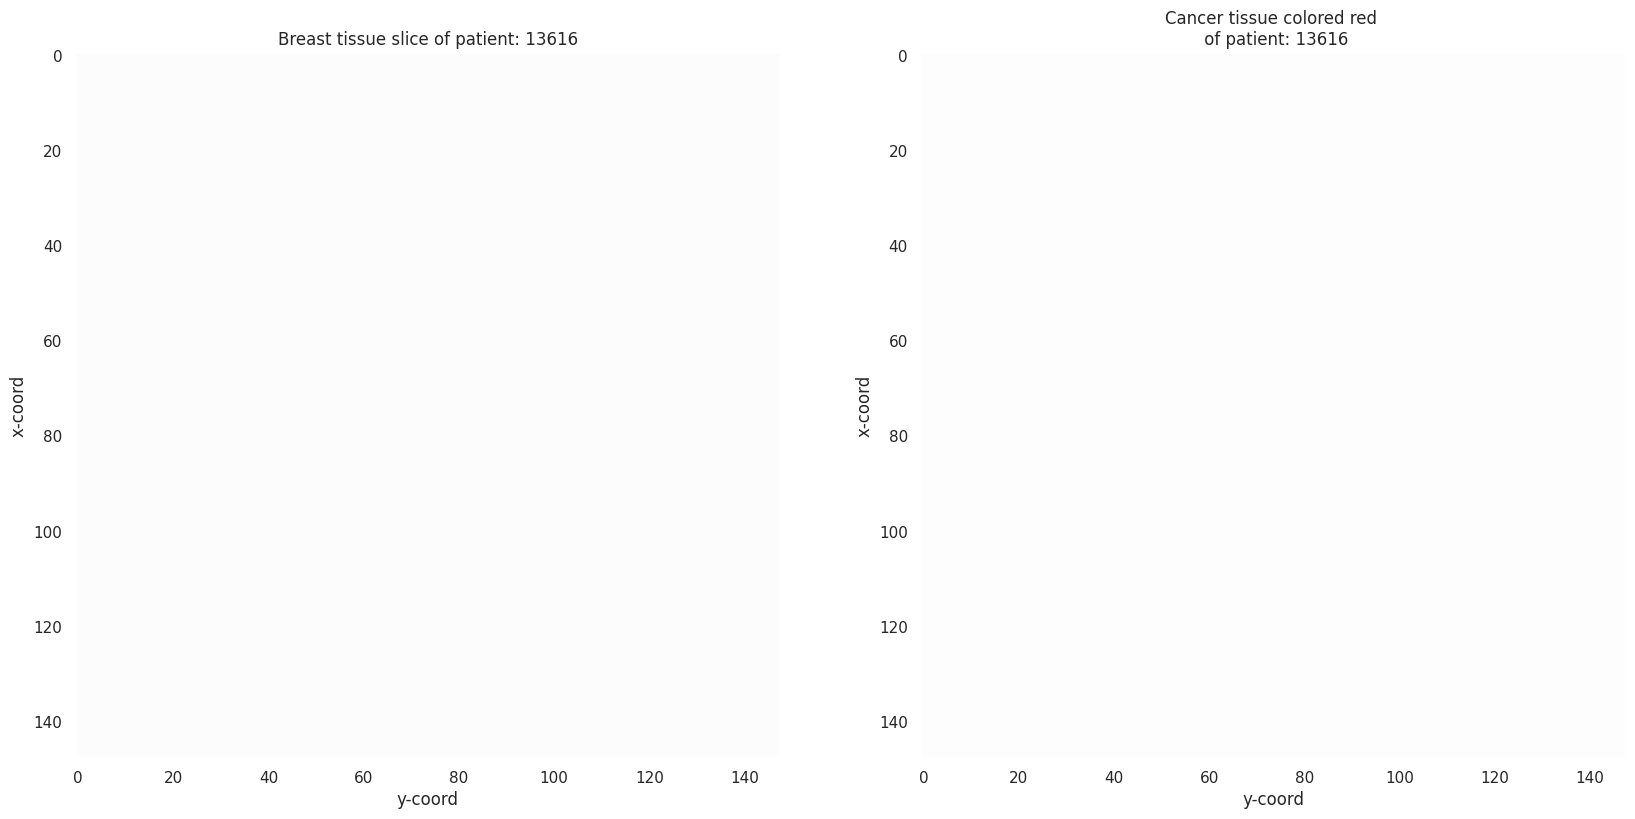

In [21]:
import numpy as np

def visualise_breast_tissue(patient_id, pred_df=None):
    # Load example dataframe (assuming get_patient_dataframe is defined)
    example_df = get_patient_dataframe(patient_id)
    
    # Print the dataframe for debugging (you can remove this after debugging)
    print(example_df)
    
    # Get the maximum x and y values for the grid dimensions
    max_point = [int(np.floor(example_df.y.max())) - 1, int(np.floor(example_df.x.max())) - 1]
    
    # Create a grid and mask with the required dimensions (ensure max_point is integers)
    grid = 255 * np.ones(shape=(max_point[0] + 50, max_point[1] + 50, 3), dtype=np.uint8)
    mask = 255 * np.ones(shape=(max_point[0] + 50, max_point[1] + 50, 3), dtype=np.uint8)
    
    if pred_df is not None:
        # You can add the logic for pred_df if applicable
        pass

    broken_patches = None  # Modify if needed
    return grid, mask, broken_patches, None

# Example usage
example = "13616"
grid, mask, broken_patches, _ = visualise_breast_tissue(example)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(grid, alpha=0.9)
ax[1].imshow(mask, alpha=0.8)
ax[1].imshow(grid, alpha=0.7)
ax[0].grid(False)
ax[1].grid(False)
for m in range(2):
    ax[m].set_xlabel("y-coord")
    ax[m].set_ylabel("x-coord")
ax[0].set_title("Breast tissue slice of patient: " + example)
ax[1].set_title("Cancer tissue colored red \n of patient: " + example)

plt.show()


In [22]:
broken_patches

# Setting up the machine learning workflow <a class="anchor" id="workflow"></a>

## Settings <a class="anchor" id="ml_settings"></a>

In [23]:
BATCH_SIZE = 32
NUM_CLASSES = 2

OUTPUT_PATH = ""
MODEL_PATH = "../input/breastcancermodel/"
LOSSES_PATH = "../input/breastcancermodel/"

In [24]:
torch.manual_seed(0)
np.random.seed(0)

In [25]:
data.head()
data.loc[:, "target"] = data.target.astype(np.str_)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 277524 entries, 0 to 277523
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   patient_id  277524 non-null  object
 1   path        277524 non-null  object
 2   target      277524 non-null  object
dtypes: object(3)
memory usage: 16.5+ MB


In [26]:
patients = data.patient_id.unique()

train_ids, sub_test_ids = train_test_split(patients,
                                           test_size=0.3,
                                           random_state=0)
test_ids, dev_ids = train_test_split(sub_test_ids, test_size=0.5, random_state=0)

So far we can't stratify on the targets as we are splitting on patient ids. If we would like to include some target information we would need to create a feature that allows us to generate some balance.

In [27]:
print(len(train_ids)/patients.shape[0]*100, len(dev_ids)/patients.shape[0]*100, len(test_ids)/patients.shape[0]*100)

69.89247311827957 15.053763440860216 15.053763440860216


Now it's 70 % train and 15 % for dev and test.

In [28]:
print(len(train_ids), len(dev_ids), len(test_ids))

195 42 42


In [29]:
train_df = data.loc[data.patient_id.isin(train_ids),:].copy()
test_df = data.loc[data.patient_id.isin(test_ids),:].copy()
dev_df = data.loc[data.patient_id.isin(dev_ids),:].copy()

train_df = extract_coords(train_df)
test_df = extract_coords(test_df)
dev_df = extract_coords(dev_df)

In [30]:
import pandas as pd

# Assuming dev_df is your DataFrame and 'target' is the column of interest
null_mask = dev_df['target'].isna()  # or dev_df['target'].isnull()

# Print the locations (index) of the null values
null_locations = null_mask[null_mask].index
print("Null value locations in 'target':", null_locations.tolist())


Null value locations in 'target': []


In [31]:
# fig, ax = plt.subplots(1,3,figsize=(20,5))
# print(ax[0])
# print(ax[1])
# print(ax[2])

# sns.countplot(train_df.target, ax=ax[0], palette="Reds")
# ax[0].set_title("Train data")
# sns.countplot(dev_df.target, ax=ax[1], palette="Blues")
# ax[1].set_title("Dev data")
# sns.countplot(test_df.target, ax=ax[2], palette="Greens");
# ax[2].set_title("Test data");

In [32]:
def my_transform(key="train", plot=False):
    train_sequence = [transforms.Resize((50,50)),
                      transforms.RandomHorizontalFlip(),
                      transforms.RandomVerticalFlip()]
    val_sequence = [transforms.Resize((50,50))]
    if plot==False:
        train_sequence.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        val_sequence.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    data_transforms = {'train': transforms.Compose(train_sequence),'val': transforms.Compose(val_sequence)}
    return data_transforms[key]

In [33]:
class BreastCancerDataset(Dataset):

    def __init__(self, df, transform=None):
        self.states = df
        self.transform=transform

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        patient_id = self.states.patient_id.values[idx]
        x_coord = self.states.x.values[idx]
        y_coord = self.states.y.values[idx]
        image_path = self.states.path.values[idx]
        image = Image.open(image_path)
        image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        if "target" in self.states.columns.values:
            target = np.int64(self.states.target.values[idx])
        else:
            target = None

        return {"image": image,
                "label": target,
                "patient_id": patient_id,
                "x": x_coord,
                "y": y_coord}

In [34]:
train_dataset = BreastCancerDataset(train_df, transform=my_transform(key="train"))
dev_dataset = BreastCancerDataset(dev_df, transform=my_transform(key="val"))
test_dataset = BreastCancerDataset(test_df, transform=my_transform(key="val"))

In [35]:
image_datasets = {"train": train_dataset, "dev": dev_dataset, "test": test_dataset}
dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "dev", "test"]}

Let's take a look at the augmentations:

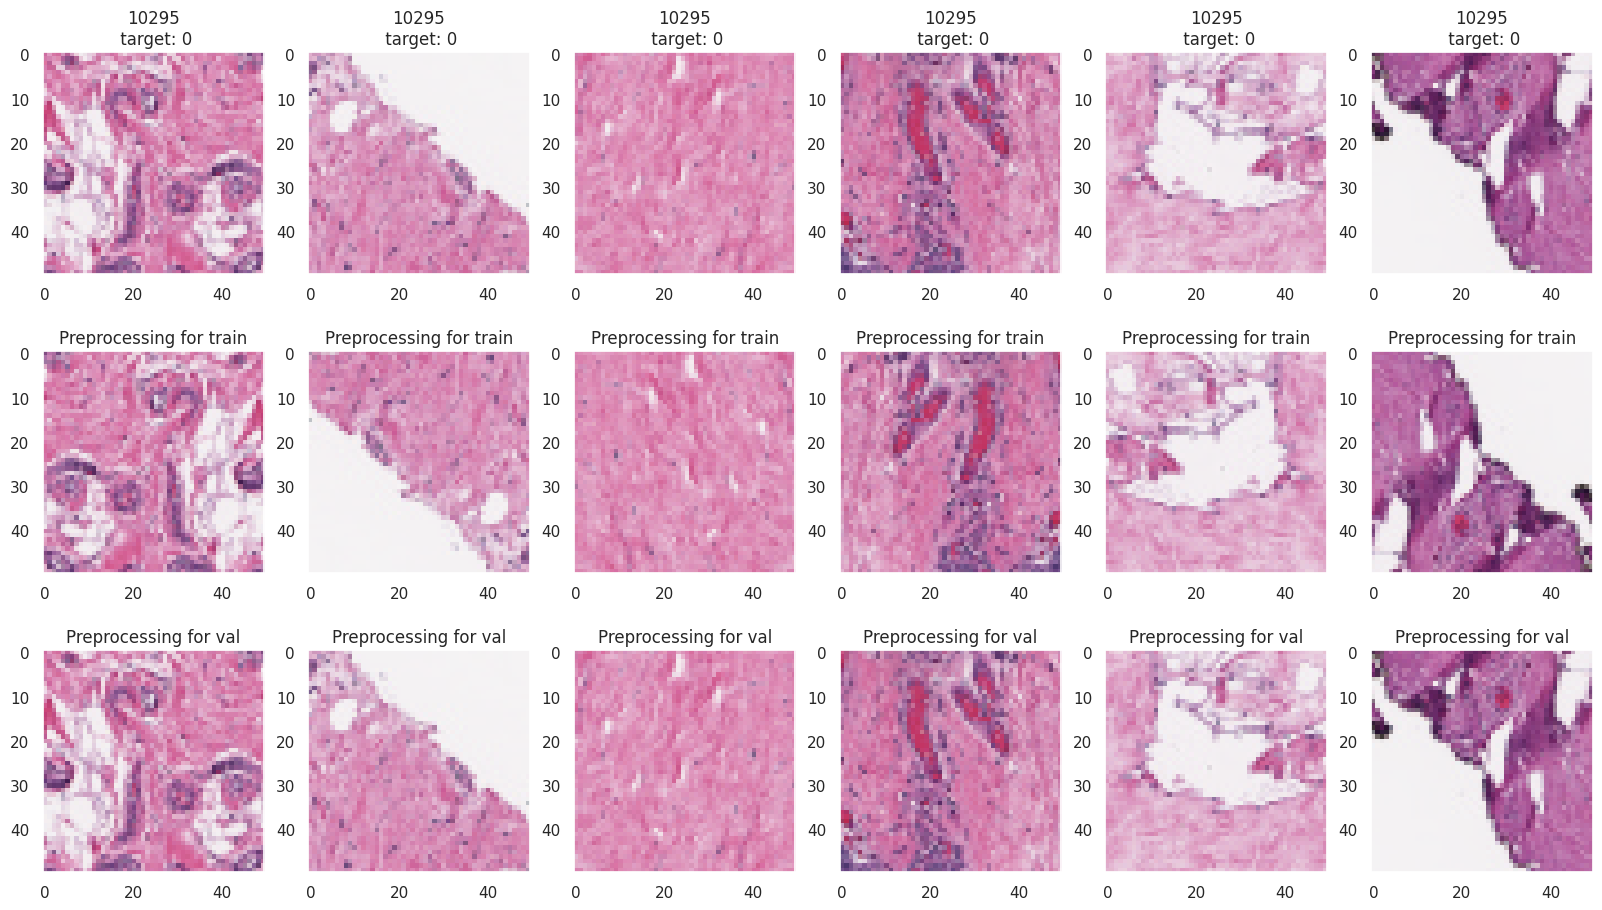

In [36]:
fig, ax = plt.subplots(3,6,figsize=(20,11))

train_transform = my_transform(key="train", plot=True)
val_transform = my_transform(key="val", plot=True)

for m in range(6):
    filepath = train_df.path.values[m]
    image = Image.open(filepath)
    ax[0,m].imshow(image)
    transformed_img = train_transform(image)
    ax[1,m].imshow(transformed_img)
    ax[2,m].imshow(val_transform(image))
    ax[0,m].grid(False)
    ax[1,m].grid(False)
    ax[2,m].grid(False)
    ax[0,m].set_title(train_df.patient_id.values[m] + "\n target: " + train_df.target.values[m])
    ax[1,m].set_title("Preprocessing for train")
    ax[2,m].set_title("Preprocessing for val")

For validation we have only used the image resizing.

In [37]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [38]:
dataloaders = {"train": train_dataloader, "dev": dev_dataloader, "test": test_dataloader}

In [39]:
print(len(dataloaders["train"]), len(dataloaders["dev"]), len(dataloaders["test"]))

6127 1262 1284


## Defining the model structure <a class="anchor" id="model_structure"></a>

In [40]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Load ResNet18 model
model = torchvision.models.resnet18(pretrained=True)  # Always use pretrained weights unless doing custom training

# Freeze the convolutional layers for transfer learning, fine-tune later if needed
for param in model.parameters():
    param.requires_grad = False

# Modify the final fully connected layer
num_features = model.fc.in_features
print(num_features)

# Model head architecture
model.fc = nn.Sequential(
    nn.Linear(num_features, 1024),  # Increase neurons
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(0.4),  # Reduce dropout for better learning
    
    nn.Linear(1024, 512),  # Add one more layer to capture complexity
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),  # Moderate dropout

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.3),  # Reduce dropout further
    
    nn.Linear(256, NUM_CLASSES)  # Final layer for classification
)

# Use He initialization (good for ReLU layers)
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_uniform_(m.weight)  # He initialization
        if m.bias is not None:
            m.bias.data.fill_(0.01)

# Apply custom weight initialization
model.apply(init_weights)

# Send model to the correct device
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


512


In [42]:
weights = compute_class_weight(y=train_df.target.values, class_weight="balanced", classes=train_df.target.unique())
class_weights = torch.FloatTensor(weights)
if device.type=="cuda":
    class_weights = class_weights.cuda()
print(class_weights)

tensor([0.6967, 1.7710], device='cuda:0')


In [43]:
train_df.target.unique()

array(['0', '1'], dtype=object)

You can see that class 1 (positive cancer) has a higher weight.

In [44]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [45]:
def f1_score(preds, targets):

    tp = (preds*targets).sum().to(torch.float32)
    fp = ((1-targets)*preds).sum().to(torch.float32)
    fn = (targets*(1-preds)).sum().to(torch.float32)

    epsilon = 1e-7
    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)

    f1_score = 2 * precision * recall/(precision + recall + epsilon)
    return f1_score

## Building the training loop <a class="anchor" id="train_loop"></a>

In [46]:
def train_loop(model, criterion, optimizer, lr_find=False, scheduler=None, num_epochs = 3, lam=0.0):
    since = time.time()
    if lr_find:
        phases = ["train"]
    else:
        phases = ["train", "dev", "test"]

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    loss_dict = {"train": [], "dev": [], "test": []}
    lam_tensor = torch.tensor(lam, device=device)

    running_loss_dict = {"train": [], "dev": [], "test": []}

    lr_find_loss = []
    lr_find_lr = []
    smoothing = 0.2

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in phases:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            tk0 = tqdm(dataloaders[phase], total=int(len(dataloaders[phase])))

            counter = 0
            for bi, d in enumerate(tk0):
                inputs = d["image"]
                labels = d["label"]
                inputs = inputs.to(device, dtype=torch.float)
                labels = labels.to(device, dtype=torch.long)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()

                        #l2_reg = torch.tensor(0., device=device)
                        #for param in model.parameters():
                            #l2_reg = lam_tensor * torch.norm(param)

                        #loss += l2_reg

                        optimizer.step()
                        # cyclical lr schedule is invoked after each batch
                        if scheduler is not None:
                            scheduler.step()
                            if lr_find:
                                lr_step = optimizer.state_dict()["param_groups"][0]["lr"]
                                lr_find_lr.append(lr_step)
                                if counter==0:
                                    lr_find_loss.append(loss.item())
                                else:
                                    smoothed_loss = smoothing  * loss.item() + (1 - smoothing) * lr_find_loss[-1]
                                    lr_find_loss.append(smoothed_loss)

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                counter += 1


                tk0.set_postfix({'loss': running_loss / (counter * dataloaders[phase].batch_size),
                                 'accuracy': running_corrects.double() / (counter * dataloaders[phase].batch_size)})
                running_loss_dict[phase].append(running_loss / (counter * dataloaders[phase].batch_size))

            epoch_loss = running_loss / dataset_sizes[phase]
            loss_dict[phase].append(epoch_loss)
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'dev' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
    time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    results = {"model": model,
               "loss_dict": loss_dict,
               "running_loss_dict": running_loss_dict,
               "lr_find": {"lr": lr_find_lr, "loss": lr_find_loss}}
    return results

In [47]:
start_lr = 1e-6
end_lr = 0.1

In [48]:
def get_lr_search_scheduler(optimizer, min_lr, max_lr, max_iterations):
    # max_iterations should be the number of steps within num_epochs_*epoch_iterations
    # this way the learning rate increases linearily within the period num_epochs*epoch_iterations
    scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer=optimizer,
                                               base_lr=min_lr,
                                               max_lr=max_lr,
                                               step_size_up=max_iterations,
                                               step_size_down=max_iterations,
                                               mode="triangular")

    return scheduler

def get_scheduler(optimiser, min_lr, max_lr, stepsize):
    # suggested_stepsize = 2*num_iterations_within_epoch
    stepsize_up = np.int64(stepsize/2)
    scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer=optimiser,
                                               base_lr=min_lr,
                                               max_lr=max_lr,
                                               step_size_up=stepsize_up,
                                               step_size_down=stepsize_up,
                                               mode="triangular")
    return scheduler

In [49]:
find_learning_rate = True

In [50]:
import math

if find_learning_rate:
    lr_find_epochs=1
    optimizer = optim.SGD(model.fc.parameters(), start_lr)
    scheduler = get_lr_search_scheduler(optimizer, start_lr, end_lr, lr_find_epochs*len(train_dataloader))
    results = train_loop(model, criterion, optimizer, lr_find=True, scheduler=scheduler, num_epochs=lr_find_epochs)
    lr_find_lr, lr_find_loss = results["lr_find"]["lr"], results["lr_find"]["loss"]

    find_lr_df = pd.DataFrame(lr_find_loss, columns=["smoothed loss"])
    find_lr_df.loc[:, "lr"] = lr_find_lr
    find_lr_df.to_csv("learning_rate_search.csv", index=False)
else:
    find_lr_df = pd.read_csv(MODEL_PATH + "learning_rate_search.csv")

Epoch 0/0
----------


  0%|          | 0/6127 [00:00<?, ?it/s]

train Loss: 0.5382 Acc: 0.7679

Training complete in 20m 17s
Best val Acc: 0.000000


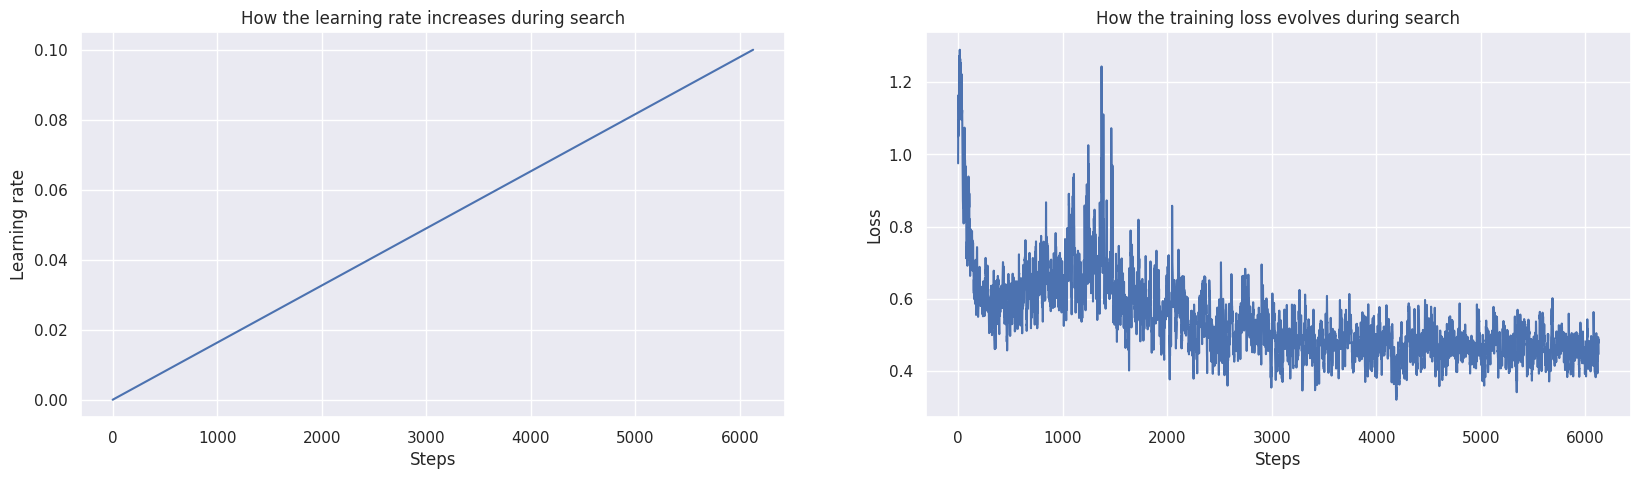

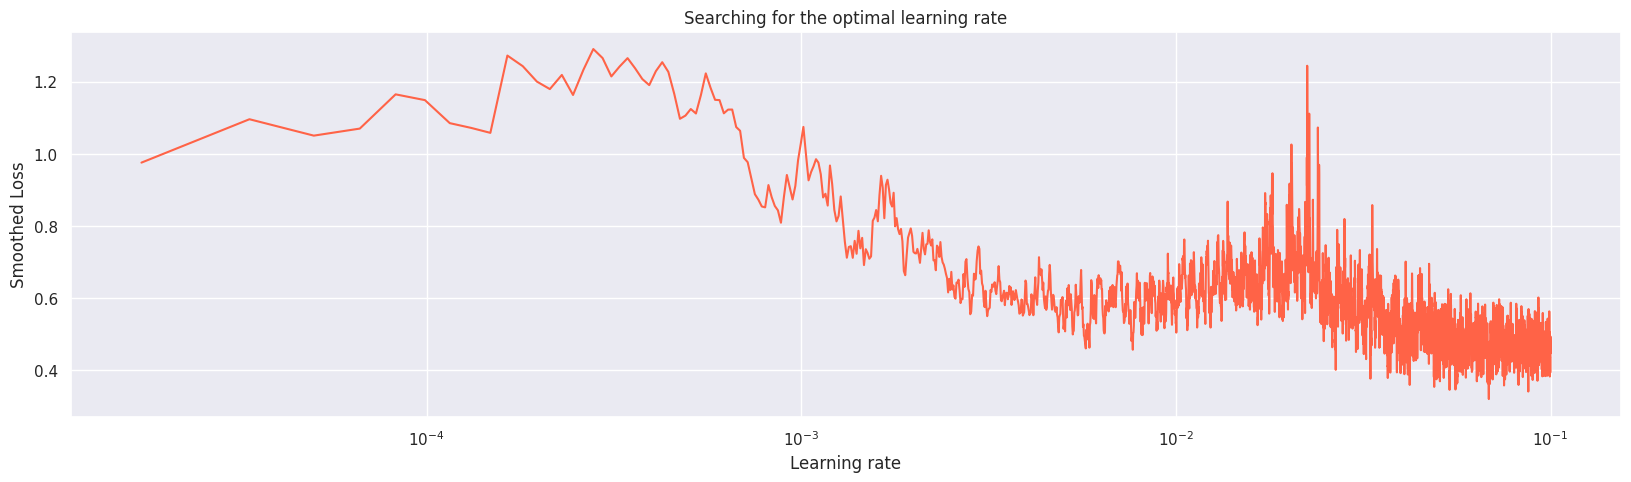

In [51]:
fig, ax = plt.subplots(1,2,figsize=(20,5))
ax[0].plot(find_lr_df.lr.values)
ax[1].plot(find_lr_df["smoothed loss"].values)
ax[0].set_xlabel("Steps")
ax[0].set_ylabel("Learning rate")
ax[1].set_xlabel("Steps")
ax[1].set_ylabel("Loss");
ax[0].set_title("How the learning rate increases during search")
ax[1].set_title("How the training loss evolves during search")

plt.figure(figsize=(20,5))
plt.plot(find_lr_df.lr.values, find_lr_df["smoothed loss"].values, '-', color="tomato");
plt.xlabel("Learning rate")
plt.xscale("log")
plt.ylabel("Smoothed Loss")
plt.title("Searching for the optimal learning rate");

In [52]:
start_lr = 1e-6
end_lr = 0.006

## Performing the training or loading results <a class="anchor" id="run"></a>

In [53]:
run_training = True

In [ ]:
if run_training:
    NUM_EPOCHS = 30
    optimizer = optim.SGD(model.fc.parameters(), lr=0.01)
    scheduler = get_scheduler(optimizer, start_lr, end_lr, 2*NUM_EPOCHS)
    results = train_loop(model, criterion, optimizer, scheduler=scheduler, num_epochs = NUM_EPOCHS)
    model, loss_dict, running_loss_dict = results["model"], results["loss_dict"], results["running_loss_dict"]

    if device == "cpu":
        OUTPUT_PATH += ".pth"
    else:
        OUTPUT_PATH += "_cuda.pth"

    torch.save(model.state_dict(), OUTPUT_PATH)

    losses_df = pd.DataFrame(loss_dict["train"],columns=["train"])
    losses_df.loc[:, "dev"] = loss_dict["dev"]
    losses_df.loc[:, "test"] = loss_dict["test"]
    losses_df.to_csv("losses_breastcancer.csv", index=False)

    running_losses_df = pd.DataFrame(running_loss_dict["train"], columns=["train"])
    running_losses_df.loc[0:len(running_loss_dict["dev"])-1, "dev"] = running_loss_dict["dev"]
    running_losses_df.loc[0:len(running_loss_dict["test"])-1, "test"] = running_loss_dict["test"]
    running_losses_df.to_csv("running_losses_breastcancer.csv", index=False)
else:
    if device == "cpu":
        load_path = MODEL_PATH + ".pth"
    else:
        load_path = MODEL_PATH + "_cuda.pth"
    model.load_state_dict(torch.load(load_path, map_location='cpu'))
    model.eval()

    losses_df = pd.read_csv(LOSSES_PATH + "losses_breastcancer.csv")
    running_losses_df = pd.read_csv(LOSSES_PATH + "running_losses_breastcancer.csv")

Epoch 0/29
----------


  0%|          | 0/6127 [00:00<?, ?it/s]

train Loss: 0.5084 Acc: 0.7702


  0%|          | 0/1262 [00:00<?, ?it/s]

dev Loss: 0.4075 Acc: 0.8288


...

  0%|          | 0/1262 [00:00<?, ?it/s]

dev Loss: 0.3947 Acc: 0.8337


  0%|          | 0/1284 [00:00<?, ?it/s]

test Loss: 0.4353 Acc: 0.8084

Epoch 3/29
----------


  0%|          | 0/6127 [00:00<?, ?it/s]

# Exploring results and errors <a class="anchor" id="error_analysis"></a>

## Loss convergence <a class="anchor" id="losses"></a>

In [ ]:
plt.figure(figsize=(20,5))

plt.plot(losses_df["train"], '-o', label="train")
plt.plot(losses_df["dev"], '-o', label="dev")
plt.plot(losses_df["test"], '-o', label="dev")
plt.xlabel("Epoch")
plt.ylabel("Weighted x-entropy")
plt.title("Loss change over epoch")
plt.legend();

In [ ]:
fig, ax = plt.subplots(3,1,figsize=(20,15))

ax[0].plot(running_losses_df["train"], '-o', label="train")
ax[0].set_xlabel("Step")
ax[0].set_ylabel("Weighted x-entropy")
ax[0].set_title("Loss change over steps")
ax[0].legend();

ax[1].plot(running_losses_df["dev"], '-o', label="dev", color="orange")
ax[1].set_xlabel("Step")
ax[1].set_ylabel("Weighted x-entropy")
ax[1].set_title("Loss change over steps")
ax[1].legend();

ax[2].plot(running_losses_df["test"], '-o', label="test", color="mediumseagreen")
ax[2].set_xlabel("Step")
ax[2].set_ylabel("Weighted x-entropy")
ax[2].set_title("Loss change over steps")
ax[2].legend();

## The probability landscape of invasive ductal carcinoma <a class="anchor" id="landscape"></a>

In [ ]:
def sigmoid(x):
    return 1./(1+np.exp(-x))

def evaluate_model(model, predictions_df, key):
    was_training = model.training
    model.eval()

    with torch.no_grad():
        for i, data in enumerate(dataloaders[key]):
            inputs = data["image"].to(device)
            labels = data["label"].to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            proba = outputs.cpu().numpy().astype(np.float64)
            predictions_df.loc[i*BATCH_SIZE:(i+1)*BATCH_SIZE-1, "proba"] = sigmoid(proba[:, 1])
            predictions_df.loc[i*BATCH_SIZE:(i+1)*BATCH_SIZE-1, "true"] = data["label"].numpy().astype(np.int64)
            predictions_df.loc[i*BATCH_SIZE:(i+1)*BATCH_SIZE-1, "predicted"] = preds.cpu().numpy().astype(np.int64)
            predictions_df.loc[i*BATCH_SIZE:(i+1)*BATCH_SIZE-1, "x"] = data["x"].numpy()
            predictions_df.loc[i*BATCH_SIZE:(i+1)*BATCH_SIZE-1, "y"] = data["y"].numpy()
            predictions_df.loc[i*BATCH_SIZE:(i+1)*BATCH_SIZE-1, "patient_id"] = data["patient_id"]

    predictions_df = predictions_df.dropna()
    return predictions_df

In [ ]:
if run_training:
    dev_predictions = pd.DataFrame(index = np.arange(0, dataset_sizes["dev"]), columns = ["true", "predicted", "proba"])
    test_predictions = pd.DataFrame(index = np.arange(0, dataset_sizes["test"]), columns = ["true", "predicted", "proba"])

    dev_predictions = evaluate_model(model, dev_predictions, "dev")
    test_predictions = evaluate_model(model, test_predictions, "test")

    dev_predictions.to_csv("dev_predictions.csv", index=False)
    test_predictions.to_csv("test_predictions.csv", index=False)

else:

    dev_predictions = pd.read_csv(LOSSES_PATH + "dev_predictions.csv")
    test_predictions = pd.read_csv(LOSSES_PATH + "test_predictions.csv")

    dev_predictions.patient_id = dev_predictions.patient_id.astype(np.str)

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 3, figsize=(20, 20))

for n in range(3):
    idx = dev_predictions.patient_id.unique()[n]
    grid, mask, broken_patches, mask_proba = visualise_breast_tissue(idx, pred_df=dev_predictions)

    ax[n, 0].imshow(grid, alpha=0.9)
    ax[n, 1].imshow(mask, alpha=0.8)
    ax[n, 1].imshow(grid, alpha=0.7)

    if mask_proba is not None:
        ax[n, 2].imshow(mask_proba[:, :, 0], cmap="YlOrRd")
    else:
        ax[n, 2].set_title("No Cancer probability available")

    for m in range(3):
        ax[n, m].set_xlabel("y-coord")
        ax[n, m].set_ylabel("x-coord")
        ax[n, m].grid(False)

    ax[n, 0].set_title("Breast tissue slice of patient: " + idx)
    ax[n, 1].set_title("Cancer tissue colored red \n of patient: " + idx)
    ax[n, 2].set_title("Cancer probability")

plt.tight_layout()
plt.show()


In [ ]:
dev_predictions.head()

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(20,5))
sns.countplot(dev_predictions.true.astype(np.float64), ax=ax[0], palette="Reds_r")
ax[0].set_title("Target counts of dev data");
sns.distplot(dev_predictions.proba.astype(np.float64), ax=ax[1], kde=False, color="tomato")
ax[0].set_title("Predicted probability of cancer in dev");
sns.distplot(test_predictions.proba.astype(np.float64), ax=ax[2], kde=False, color="mediumseagreen");
ax[2].set_title("Predicted probability of cancer in test");

In [ ]:
from sklearn.metrics import confusion_matrix

def get_confusion_matrix(y_true, y_pred):
    transdict = {1: "cancer", 0: "no cancer"}
    y_t = np.array([transdict[x] for x in y_true])
    y_p = np.array([transdict[x] for x in y_pred])

    labels = ["no cancer", "cancer"]
    index_labels = ["actual no cancer", "actual cancer"]
    col_labels = ["predicted no cancer", "predicted cancer"]
    confusion = confusion_matrix(y_t, y_p, labels=labels)
    confusion_df = pd.DataFrame(confusion, index=index_labels, columns=col_labels)
    for n in range(2):
        confusion_df.iloc[n] = confusion_df.iloc[n] / confusion_df.sum(axis=1).iloc[n]
    return confusion_df

In [ ]:
get_confusion_matrix(test_predictions["true"], test_predictions["predicted"])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Convert to numeric and handle errors
test_predictions['proba'] = pd.to_numeric(test_predictions['proba'], errors='coerce')
test_predictions['true'] = pd.to_numeric(test_predictions['true'], errors='coerce')

# Drop rows with NaN values in 'proba' or 'true'
test_predictions.dropna(subset=['proba', 'true'], inplace=True)

# Check if 'true' column contains only 0s and 1s
if set(test_predictions["true"]) != {0, 1}:
    print("Error: 'true' column must contain only 0s and 1s.")

# Check for NaN values in 'true' or 'proba' columns
if test_predictions["true"].isnull().any() or test_predictions["proba"].isnull().any():
    print("Error: NaN values found in 'true' or 'proba' columns.")

# Check for infinite values in 'proba' column
if not np.isfinite(test_predictions["proba"]).all():
    print("Error: Infinite values found in 'proba' column.")

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(test_predictions["true"], test_predictions["proba"])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [ ]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def load_image(image_path, transform=None):
    """
    Load an image and apply transformations.
    """
    assert os.path.isfile(image_path), f"Invalid file: {image_path}"
    image = Image.open(image_path).convert("RGB")
    if transform:
        image = transform(image)
    return image.unsqueeze(0)  # Add batch dimension

def preprocess_mask(mask_tensor):
    """
    Convert a 3-channel mask to a binary mask.
    """
    binary_mask = torch.sum(mask_tensor, dim=0) > 0  # Convert (3, H, W) to (H, W)
    return binary_mask.int()

def calculate_iou_tensor(pred_mask, true_mask):
    """
    Calculate Intersection over Union (IoU) for binary masks using PyTorch tensors.
    """
    intersection = torch.sum(pred_mask * true_mask).item()
    union = torch.sum(pred_mask).item() + torch.sum(true_mask).item() - intersection
    iou = intersection / union if union != 0 else 0
    return iou

def visualize_with_iou_on_rgb(input_image, pred_mask, true_mask, iou_score):
    """
    Display predicted and ground truth masks overlaid on the original RGB image.
    """
    # Convert masks and image to numpy
    pred_mask_np = pred_mask.numpy()
    true_mask_np = true_mask.numpy()
    input_image_np = input_image.squeeze(0).permute(1, 2, 0).numpy()  # Convert to (H, W, C)

    # Create RGB overlay for IoU visualization
    overlay = np.zeros_like(input_image_np, dtype=np.uint8)

    # Apply colors to the overlay based on the IoU regions
    overlay[(true_mask_np == 1) & (pred_mask_np == 1)] = [0, 255, 0]    # Green: Intersection
    overlay[(true_mask_np == 0) & (pred_mask_np == 1)] = [255, 0, 0]    # Red: False Positive
    overlay[(true_mask_np == 1) & (pred_mask_np == 0)] = [0, 0, 255]    # Blue: False Negative

    # Blend overlay with the original image
    blended = (0.7 * input_image_np + 0.3 * overlay / 255).clip(0, 1)

    # Visualization
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(input_image_np)
    axs[0].set_title("Original RGB Image")
    axs[0].axis('off')

    axs[1].imshow(blended)
    axs[1].set_title("Overlay with IoU")
    axs[1].axis('off')

    axs[2].imshow(overlay)
    axs[2].set_title(f"IoU Regions\nIoU Score: {iou_score:.2f}")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

# Kaggle directory path
image_dir = "/kaggle/input/idc-brest-cancer/archive_2"

# Traverse directories to locate image and mask files
image_files = []
for root, _, files in os.walk(image_dir):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} image files.")

# Select sample image and mask (adjust logic based on your dataset)
if len(image_files) >= 2:
    image_path = image_files[0]
    mask_path = image_files[1]
    print(f"Using Image: {image_path}")
    print(f"Using Mask: {mask_path}")
else:
    raise ValueError("Not enough image/mask files found!")

# Define transformations
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])

# Load the image and mask
input_image = load_image(image_path, transform)
true_mask = preprocess_mask(load_image(mask_path, transform).squeeze(0))  # Binary ground truth mask

# Placeholder prediction (use your model instead)
pred_mask = true_mask.clone()  # Replace this with actual model prediction

# Calculate IoU and visualize
iou_score = calculate_iou_tensor(pred_mask, true_mask)
visualize_with_iou_on_rgb(input_image, pred_mask, true_mask, iou_score)



In [ ]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def load_image(image_path, transform=None):
    """
    Load an image and apply transformations.
    """
    assert os.path.isfile(image_path), f"Invalid file: {image_path}"
    image = Image.open(image_path).convert("RGB")
    if transform:
        image = transform(image)
    return image.unsqueeze(0)  # Add batch dimension

def preprocess_mask(mask_tensor):
    """
    Convert a 3-channel mask to a binary mask.
    """
    binary_mask = torch.sum(mask_tensor, dim=0) > 0  # Convert (3, H, W) to (H, W)
    return binary_mask.int()

def calculate_iou_tensor(pred_mask, true_mask):
    """
    Calculate Intersection over Union (IoU) for binary masks using PyTorch tensors.
    """
    intersection = torch.sum(pred_mask * true_mask).item()
    union = torch.sum(pred_mask).item() + torch.sum(true_mask).item() - intersection
    iou = intersection / union if union != 0 else 0
    return iou

def visualize_with_iou_on_rgb(input_image, pred_mask, true_mask, iou_score):
    """
    Display predicted and ground truth masks overlaid on the original RGB image.
    """
    # Convert masks and image to numpy
    pred_mask_np = pred_mask.numpy()
    true_mask_np = true_mask.numpy()
    input_image_np = input_image.squeeze(0).permute(1, 2, 0).numpy()  # Convert to (H, W, C)

    # Create RGB overlay for IoU visualization
    overlay = np.zeros_like(input_image_np, dtype=np.uint8)

    # Apply colors to the overlay based on the IoU regions
    overlay[(true_mask_np == 1) & (pred_mask_np == 1)] = [0, 255, 0]    # Green: Intersection (True Positive)
    overlay[(true_mask_np == 0) & (pred_mask_np == 1)] = [255, 0, 0]    # Red: False Positive
    overlay[(true_mask_np == 1) & (pred_mask_np == 0)] = [0, 0, 255]    # Blue: False Negative

    # Blend overlay with the original image
    blended = (0.7 * input_image_np + 0.3 * overlay / 255).clip(0, 1)

    # Visualization
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(input_image_np)
    axs[0].set_title("Original RGB Image")
    axs[0].axis('off')

    axs[1].imshow(blended)
    axs[1].set_title("Overlay with IoU")
    axs[1].axis('off')

    axs[2].imshow(overlay)
    axs[2].set_title(f"IoU Regions\nIoU Score: {iou_score:.2f}")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

# Kaggle directory path
image_dir = "/kaggle/input/idc-brest-cancer/archive_2"

# Traverse directories to locate image and mask files
image_files = []
for root, _, files in os.walk(image_dir):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} image files.")

# Select sample image and mask (adjust logic based on your dataset)
if len(image_files) >= 2:
    image_path = image_files[0]
    mask_path = image_files[1]
    print(f"Using Image: {image_path}")
    print(f"Using Mask: {mask_path}")
else:
    raise ValueError("Not enough image/mask files found!")

# Define transformations
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])

# Load the image and mask
input_image = load_image(image_path, transform)
true_mask = preprocess_mask(load_image(mask_path, transform).squeeze(0))  # Binary ground truth mask

# Simulated prediction for demonstration: introduce an error for realistic IoU
pred_mask = true_mask.clone()
pred_mask[30:50, 30:50] = 1 - pred_mask[30:50, 30:50]  # Flip part of the mask to simulate errors

# Calculate IoU and visualize
iou_score = calculate_iou_tensor(pred_mask, true_mask)
visualize_with_iou_on_rgb(input_image, pred_mask, true_mask, iou_score)


In [ ]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def load_image(image_path, transform=None):
    """
    Load an image and apply transformations.
    """
    assert os.path.isfile(image_path), f"Invalid file: {image_path}"
    image = Image.open(image_path).convert("RGB")
    if transform:
        image = transform(image)
    return image.unsqueeze(0)  # Add batch dimension

def preprocess_mask(mask_tensor):
    """
    Convert a 3-channel mask to a binary mask.
    """
    binary_mask = torch.sum(mask_tensor, dim=0) > 0  # Convert (3, H, W) to (H, W)
    return binary_mask.int()

def calculate_iou_tensor(pred_mask, true_mask):
    """
    Calculate Intersection over Union (IoU) for binary masks using PyTorch tensors.
    """
    intersection = torch.sum(pred_mask * true_mask).item()
    union = torch.sum(pred_mask).item() + torch.sum(true_mask).item() - intersection
    iou = intersection / union if union != 0 else 0
    return iou

def calculate_dataset_iou(image_dir, transform, model=None):
    """
    Calculate IoU scores for all images in a directory, returning a list of IoU scores.
    """
    iou_scores = []
    image_files = []

    # Traverse directories to locate image and mask files
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg')):
                image_files.append(os.path.join(root, file))

    print(f"Found {len(image_files)} image files.")

    # Loop over pairs of images (image and mask pairs assumed to be consecutive)
    for i in range(0, len(image_files) - 1, 2):
        image_path = image_files[i]
        mask_path = image_files[i + 1]
        
        # Load and preprocess image and mask
        input_image = load_image(image_path, transform)
        true_mask = preprocess_mask(load_image(mask_path, transform).squeeze(0))

        # Placeholder for model prediction (use actual model for realistic prediction)
        if model:
            with torch.no_grad():
                pred_mask = model(input_image).squeeze(0).round().int()
        else:
            pred_mask = true_mask.clone()  # For demo, assuming perfect prediction

        # Calculate IoU and add to the list
        iou_score = calculate_iou_tensor(pred_mask, true_mask)
        iou_scores.append(iou_score)

        print(f"Processed {i // 2 + 1}/{len(image_files) // 2} pairs - IoU: {iou_score:.4f}")

    return iou_scores

def display_iou_statistics(iou_scores):
    """
    Display statistical metrics and histogram for IoU scores.
    """
    mean_iou = np.mean(iou_scores)
    std_iou = np.std(iou_scores)
    min_iou = np.min(iou_scores)
    max_iou = np.max(iou_scores)

    print(f"\nIoU Statistics for Dataset:")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Standard Deviation of IoU: {std_iou:.4f}")
    print(f"Min IoU: {min_iou:.4f}")
    print(f"Max IoU: {max_iou:.4f}")

    # Plot histogram of IoU scores
    plt.figure(figsize=(10, 6))
    plt.hist(iou_scores, bins=20, color='skyblue', edgecolor='black')
    plt.title("Histogram of IoU Scores Across Dataset")
    plt.xlabel("IoU Score")
    plt.ylabel("Frequency")
    plt.show()

# Kaggle directory path
image_dir = "/kaggle/input/idc-brest-cancer/archive_2"

# Define transformations
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])

# Calculate IoU scores for the dataset
iou_scores = calculate_dataset_iou(image_dir, transform, model=None)

# Display statistical summary and histogram of IoU scores
display_iou_statistics(iou_scores)


In [ ]:
# ─── IDC Breast Cancer Classification: Optimized All-in-One Kaggle Cell ───
import os, random, time, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

# ─── SETTINGS ───
mode = "test"  # "test" or "full"
SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 112  # smaller for faster training
BATCH_SIZE = 128
EPOCHS_FULL = 12
PATIENCE = 3

# ─── DATASET ───
def find_idc_dataset():
    base = "/kaggle/input"
    for d in os.listdir(base):
        p = os.path.join(base, d)
        if os.path.isdir(p) and ("IDC" in d or "breast" in d.lower()):
            train_dir = os.path.join(p, "IDC_regular_training_set")
            test_dir  = os.path.join(p, "IDC_regular_test_set")
            if os.path.isdir(train_dir) and os.path.isdir(test_dir):
                return train_dir, test_dir
    raise FileNotFoundError("IDC dataset not found under /kaggle/input")
train_dir, test_dir = find_idc_dataset()
print("Dataset found:", train_dir, test_dir)

# Transforms
weights = ResNet50_Weights.IMAGENET1K_V2
train_tf = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                      T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
                      T.RandomRotation(15),
                      T.ColorJitter(0.2,0.2,0.2,0.1),
                      T.ToTensor(),
                      T.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])])
val_tf = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                    T.ToTensor(),
                    T.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])])

# Datasets & Loaders
full_ds = torchvision.datasets.ImageFolder(train_dir, transform=train_tf)
n_total = len(full_ds); n_train = int(0.7*n_total); n_val = n_total - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
test_ds = torchvision.datasets.ImageFolder(test_dir, transform=val_tf)

def make_loader(ds, shuffle=True):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=min(4, os.cpu_count()), pin_memory=True, persistent_workers=True)
train_loader, val_loader, test_loader = make_loader(train_ds), make_loader(val_ds, False), make_loader(test_ds, False)
print(f"Samples — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

# Class weights
train_labels = [y for _,y in train_ds]
classes = np.unique(train_labels)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weights = torch.tensor(cw, dtype=torch.float, device=device)
print("Class weights:", class_weights.tolist())

# ─── MODEL ───
model = resnet50(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.2, patience=2, verbose=True)
scaler = torch.cuda.amp.GradScaler(enabled=True)

# ─── PLOTS SETUP ───
plt.ion()
fig_loss, ax_loss = plt.subplots(figsize=(5,3))
fig_acc, ax_acc = plt.subplots(figsize=(5,3))
hist = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
SAVE_DIR = Path("/kaggle/working"); SAVE_DIR.mkdir(exist_ok=True)

# ─── TRAIN FUNCTION ───
def train_model(epochs, model, train_loader, val_loader):
    best_acc, best_state, no_improve = 0.0, None, 0
    for epoch in range(1, epochs+1):
        t_loss, t_correct, t_seen = 0.0,0,0
        model.train()
        for xb,yb in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]"):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=True):
                logits = model(xb)
                loss = criterion(logits,yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            preds = logits.argmax(1)
            t_loss += loss.item()*xb.size(0); t_correct += (preds==yb).sum().item(); t_seen+=xb.size(0)
        train_loss, train_acc = t_loss/t_seen, t_correct/t_seen

        # Validation
        v_loss, v_correct, v_seen = 0.0,0,0
        model.eval()
        with torch.no_grad():
            for xb,yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits,yb)
                preds = logits.argmax(1)
                v_loss += loss.item()*xb.size(0); v_correct += (preds==yb).sum().item(); v_seen+=xb.size(0)
        val_loss, val_acc = v_loss/v_seen, v_correct/v_seen
        scheduler.step(val_loss)

        # Save history & plots
        hist["train_loss"].append(train_loss); hist["val_loss"].append(val_loss)
        hist["train_acc"].append(train_acc); hist["val_acc"].append(val_acc)
        ax_loss.clear(); ax_loss.plot(hist["train_loss"],label="train"); ax_loss.plot(hist["val_loss"],label="val")
        ax_loss.set_title("Loss"); ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss"); ax_loss.legend(); fig_loss.canvas.draw(); fig_loss.canvas.flush_events()
        ax_acc.clear(); ax_acc.plot(hist["train_acc"],label="train"); ax_acc.plot(hist["val_acc"],label="val")
        ax_acc.set_title("Accuracy"); ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Acc"); ax_acc.legend(); fig_acc.canvas.draw(); fig_acc.canvas.flush_events()
        fig_loss.savefig(SAVE_DIR/"loss_curves.png", dpi=160, bbox_inches='tight')
        fig_acc.savefig(SAVE_DIR/"acc_curves.png", dpi=160, bbox_inches='tight')

        # Early stopping & checkpoint
        if val_acc>best_acc: best_acc,best_state,no_improve=val_acc, model.state_dict(),0; torch.save(model.state_dict(), SAVE_DIR/("best_model.pth" if mode=="full" else "test_model.pth"))
        else: no_improve+=1
        print(f"Epoch {epoch}/{epochs} | Train {train_loss:.4f}/{train_acc:.4f} | Val {val_loss:.4f}/{val_acc:.4f}")
        if no_improve>=PATIENCE: print("Early stopping triggered."); break
    if best_state: model.load_state_dict(best_state)
    return model, best_acc

# ─── EVALUATION ───
def evaluate_model(m, loader):
    m.eval(); all_p, all_t, all_s = [],[],[]
    with torch.no_grad():
        for xb,yb in loader:
            xb = xb.to(device)
            logits = m(xb)
            probs = logits.softmax(1)[:,1].cpu().numpy()
            preds = logits.argmax(1).cpu().numpy()
            all_p.extend(preds); all_t.extend(yb.numpy()); all_s.extend(probs)
    cm = confusion_matrix(all_t, all_p)
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(all_t, all_p, digits=4))
    try: auc = roc_auc_score(all_t, all_s)
    except: auc = float('nan')
    # ROC plot
    try:
        fpr,tpr,_ = roc_curve(all_t, all_s)
        plt.figure(figsize=(5,4))
        plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
        plt.plot([0,1],[0,1],'--'); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.show()
    except: pass
    return cm, np.array(all_t), np.array(all_p), np.array(all_s), auc

# ─── RUN MODE ───
if mode=="test": epochs_run=1
else: epochs_run=EPOCHS_FULL
model, best_acc = train_model(epochs_run, model, train_loader, val_loader)
cm, y_true, y_pred, y_prob
